### Proyecto 1: Análisis y Predicción de Ventas en una Tienda de Retail

#### Objetivo: Realizar un análisis exploratorio de datos (EDA) completo, preprocesamiento y benchmarking de técnicas de machine learning para predecir ventas en una tienda de retail. Además, generar un análisis de métricas y crear una presentación de una página (one-page) en PPT para explicar los resultados. Todo el trabajo debe ser subido como una versión de liberación (v1.0.0) en GitHub.

In [98]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report,ConfusionMatrixDisplay, f1_score, precision_score, recall_score ,roc_auc_score , roc_curve , auc, confusion_matrix
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib



#### 1.- Carga y Exploración Inicial de Datos:
- 1.1.1 Cargar el dataset y revisar su estructura básica.


In [99]:
# 1.1 Cargar el dataset
df = pd.read_csv('data/retail_sales_dataset.csv')

print("\ndimensiones")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("\nprimeras 5 filas\n")
display(df.head(10))

# los ultimos 5 registros
display("\nultimos 5 registros : \n",df.tail())


print("\n nombres de las columnas \n")
display(df.columns.tolist())

print("\ntipos de datos \n")
print(df.info())

print("\n estadisticas descriptivas \n")
display(df.describe())

print("\n tipo columnas \n")
display(df.dtypes)



dimensiones
Filas: 500, Columnas: 15


primeras 5 filas



,OrderID,OrderDate,Branch,City,CustomerType,Gender,ProductLine,UnitPrice,Quantity,Payment,Total,COGS,GrossIncome,GrossMargin,Rating
0,ORD1000,2024-01-01,C,Guadalajara,New,Female,Audio,1301.83,2,Cash,2603.66,1955.02,648.64,24.91,6.1
1,ORD1001,2024-01-02,A,Guadalajara,New,Male,Laptop,802.67,2,Cash,1605.34,1205.41,399.93,24.91,7.9
2,ORD1002,2024-01-03,C,Monterrey,New,Female,Accessories,744.81,4,Cash,2979.24,2237.03,742.21,24.91,4.7
3,ORD1003,2024-01-04,C,Guadalajara,New,Female,Gaming,87.18,3,Cash,261.54,196.38,65.16,24.91,9.3
4,ORD1004,2024-01-05,A,Mexico City,Returning,Male,Smartphone,544.81,3,Cash,1634.43,1227.25,407.18,24.91,7.0
5,ORD1005,2024-01-06,A,Mexico City,New,Female,TV,601.28,3,Cash,1803.84,1354.46,449.38,24.91,6.7
6,ORD1006,2024-01-07,C,Mexico City,Returning,Male,Smartphone,628.29,4,Ewallet,2513.16,1887.06,626.10,24.91,7.5
7,ORD1007,2024-01-08,B,Monterrey,Returning,Male,TV,891.25,2,Cash,1782.50,1338.43,444.07,24.91,7.7
8,ORD1008,2024-01-09,C,Guadalajara,New,Female,Laptop,823.72,4,Credit Card,3294.88,2474.04,820.84,24.91,4.4
9,ORD1009,2024-01-10,C,Mexico City,Returning,Male,Audio,931.46,2,Cash,1862.92,1398.82,464.10,24.91,8.1


'\nultimos 5 registros : \n'

,OrderID,OrderDate,Branch,City,CustomerType,Gender,ProductLine,UnitPrice,Quantity,Payment,Total,COGS,GrossIncome,GrossMargin,Rating
495,ORD1495,2025-05-10,B,Guadalajara,New,Male,Laptop,1139.49,4,Cash,4557.96,3422.45,1135.51,24.91,5.6
496,ORD1496,2025-05-11,B,Guadalajara,Returning,Female,TV,1002.58,4,Cash,4010.32,3011.24,999.08,24.91,7.6
497,ORD1497,2025-05-12,A,Monterrey,Returning,Male,Audio,1437.09,1,Credit Card,1437.09,1079.07,358.02,24.91,9.2
498,ORD1498,2025-05-13,B,Monterrey,Returning,Male,Smartphone,149.99,3,Cash,449.97,337.87,112.10,24.91,9.7
499,ORD1499,2025-05-14,C,Mexico City,New,Male,Gaming,132.73,4,Cash,530.92,398.65,132.27,24.91,4.6



 nombres de las columnas 



['OrderID',
 'OrderDate',
 'Branch',
 'City',
 'CustomerType',
 'Gender',
 'ProductLine',
 'UnitPrice',
 'Quantity',
 'Payment',
 'Total',
 'COGS',
 'GrossIncome',
 'GrossMargin',
 'Rating']


tipos de datos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       500 non-null    object 
 1   OrderDate     500 non-null    object 
 2   Branch        500 non-null    object 
 3   City          500 non-null    object 
 4   CustomerType  500 non-null    object 
 5   Gender        500 non-null    object 
 6   ProductLine   500 non-null    object 
 7   UnitPrice     500 non-null    float64
 8   Quantity      500 non-null    int64  
 9   Payment       500 non-null    object 
 10  Total         500 non-null    float64
 11  COGS          500 non-null    float64
 12  GrossIncome   500 non-null    float64
 13  GrossMargin   500 non-null    float64
 14  Rating        500 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 58.7+ KB
None

 estadisticas descriptivas 



,UnitPrice,Quantity,Total,COGS,GrossIncome,GrossMargin,Rating
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,771.576080,2.568000,2010.728820,1509.802560,500.92626,24.910080,6.986200
std,416.609207,1.124235,1460.680167,1096.785766,363.89440,0.000892,1.747724
min,54.670000,1.000000,60.970000,45.780000,15.19000,24.910000,4.000000
25%,399.555000,2.000000,818.462500,614.565000,203.89750,24.910000,5.600000
50%,790.690000,3.000000,1641.730000,1232.730000,409.00000,24.910000,7.000000
75%,1119.307500,4.000000,2989.970000,2245.087500,744.88250,24.910000,8.500000
max,1497.600000,4.000000,5954.520000,4471.090000,1483.43000,24.920000,10.000000



 tipo columnas 



OrderID          object
OrderDate        object
Branch           object
City             object
CustomerType     object
Gender           object
ProductLine      object
UnitPrice       float64
Quantity          int64
Payment          object
Total           float64
COGS            float64
GrossIncome     float64
GrossMargin     float64
Rating          float64
dtype: object

- 1.1.2 Describir las variables y su distribución.


|	Columna	|	Tipo	|	Descripción	|
|	 ---------------	|	 ---------------	|	 --------------	|
|'	OrderID	 '|	str	|	Identificador único de cada orden	|
|'	OrderDate	 '|	str	|	Fecha de la orden (formato YYYY-MM-DD)	|
|'	Branch	 '|	str	|	Sucursal (A, B, C)	|
|'	City	 '|	str	|	Ciudad de la sucursal	|
|'	CustomerType	 '|	str	|	Tipo de cliente (New / Returning)	|
|'	Gender	 '|	str	|	Género del cliente (Male / Female)	|
|'	ProductLine	 '|	str	|	Línea de producto (Audio, Laptop, Accessories, Gaming, Smartphone, TV)	|
|'	UnitPrice	 '|	float64	|	Precio unitario del producto	|
|'	Quantity	 '|	int64	|	Cantidad de unidades vendidas por orden	|
|'	Payment	 '|	str	|	Método de pago (Cash, Ewallet, Credit Card)	|
|'	Total	 '|	float64	|	Total pagado por la orden (UnitPrice × Quantity)	|
|'	COGS	 '|	float64	|	Costo de los bienes vendidos	|
|'	GrossIncome	 '|	float64	|	Ingreso bruto (Total - COGS)	|
|'	GrossMargin	 '|	float64	|	Margen bruto porcentual	|
|'	Rating	 '|	float64	|	Calificación del cliente (1-10)	|


- 1.1.3 Identificar y tratar valores nulos y outliers.

In [100]:
df = df.drop(columns=['GrossMargin'])
print("Columnas originales:", df.columns.tolist())

print(" - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).")

for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")

# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
print("\nDatos nulos totales : ", df.isnull().sum().sum())

print("\nNo se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.")

df.replace(np.nan, 0, inplace=True)            

Columnas originales: ['OrderID', 'OrderDate', 'Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'UnitPrice', 'Quantity', 'Payment', 'Total', 'COGS', 'GrossIncome', 'Rating']
 - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
• OrderID              -> 500 únicos
  Lista de Valores :   ['ORD1000' 'ORD1001' 'ORD1002' 'ORD1003' 'ORD1004' 'ORD1005' 'ORD1006'
 'ORD1007' 'ORD1008' 'ORD1009' 'ORD1010' 'ORD1011' 'ORD1012' 'ORD1013'
 'ORD1014' 'ORD1015' 'ORD1016' 'ORD1017' 'ORD1018' 'ORD1019' 'ORD1020'
 'ORD1021' 'ORD1022' 'ORD1023' 'ORD1024' 'ORD1025' 'ORD1026' 'ORD1027'
 'ORD1028' 'ORD1029' 'ORD1030' 'ORD1031' 'ORD1032' 'ORD1033' 'ORD1034'
 'ORD1035' 'ORD1036' 'ORD1037' 'ORD1038' 'ORD1039' 'ORD1040' 'ORD1041'
 'ORD1042' 'ORD1043' 'ORD1044' 'ORD1045' 'ORD1046' 'ORD1047' 'ORD1048'
 'ORD1049' 'ORD1050' 'ORD1051' 'ORD1052' 'ORD1053' 'ORD1054' 'ORD1055'
 'ORD1056' 'ORD1057' 'ORD1058' 'ORD1059' 'ORD1060' 'ORD1061' 'ORD1062'
 'ORD1063' 

In [101]:
# deteccion de outliarns en el dataframe
print("\n deteccion de outliarns en el dataframe.\n")
# columnas numericas
colum_numericas = [col for col in df if df[col].dtype in ['int64', 'float64']]

print("\n columnas numericas : ", colum_numericas)

# columnas categoricas
colum_categoricas = [col for col in df if df[col].dtype == 'object']

print("\n columnas categoricas :  ", colum_categoricas, "\n")

def deteccion_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    outliers = df_e[(df_e[column] < limit_inf) | (df_e[column] > limit_sup)]
    return outliers, limit_inf, limit_sup

def remover_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    df_out = df_e[(df_e[column] >= limit_inf) & (df_e[column] <= limit_sup)]
    return df_out

def mostrar_correccion_outliers(df_lim, column, arr_outliers):
   # print("arr_outliers", arr_outliers[column])

    existe = any(arr== column for arr in arr_outliers)
    #print("existe : ", existe)
    if existe: 
        outliers = df_lim[(df_lim[column] < arr_outliers[column]['lower']) | (df_lim[column] > arr_outliers[column]['upper'])]
 #       print(f"outliers {df_lim[column]} " )
 #       display("mostrar outliers", outliers)
        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        print(f"{column:18} -> cantidad de outliers = {count:3} | limites : [{arr_outliers[column]['lower']:,.2f}, {arr_outliers[column]['upper']:,.2f}]")

arr_outliers = {}

for col in colum_numericas:
        outliers, lower, upper = deteccion_outliers(df, col)
        # Guardas los valores

        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        if count > 0:
            print(f"{col:18} -> cantidad de outliers = {count:3} | limites : [{lower:,.2f}, {upper:,.2f}]")
            nombre_outlier = col
            arr_outliers.update({nombre_outlier: {'upper': upper, 'lower': lower}})




 deteccion de outliarns en el dataframe.


 columnas numericas :  ['UnitPrice', 'Quantity', 'Total', 'COGS', 'GrossIncome', 'Rating']

 columnas categoricas :   ['OrderID', 'OrderDate', 'Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'Payment'] 



In [102]:
print("\nCorrección de outliers")

df_clean = df.copy()

for col in colum_numericas:            
    df_clean = remover_outliers(df_clean, col)



print("\n mostrar corrección de outlierns. \n ")
#display('df_limpio',df_limpio['length'])
#display(arr_outliers)
for col in colum_numericas:
    #print(f"columna : {col} ")
    mostrar_correccion_outliers(df_clean, col, arr_outliers)


Corrección de outliers

 mostrar corrección de outlierns. 
 


### 1.2 Análisis de Correlación:
**- 1.2.2 Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables.**


Matriz de correlación (Pearson):


,UnitPrice,Quantity,Total,COGS,GrossIncome,Rating
UnitPrice,1.000,0.063,0.733,0.733,0.733,-0.015
Quantity,0.063,1.000,0.645,0.645,0.645,0.057
Total,0.733,0.645,1.000,1.000,1.000,0.010
COGS,0.733,0.645,1.000,1.000,1.000,0.010
GrossIncome,0.733,0.645,1.000,1.000,1.000,0.010
Rating,-0.015,0.057,0.010,0.010,0.010,1.000


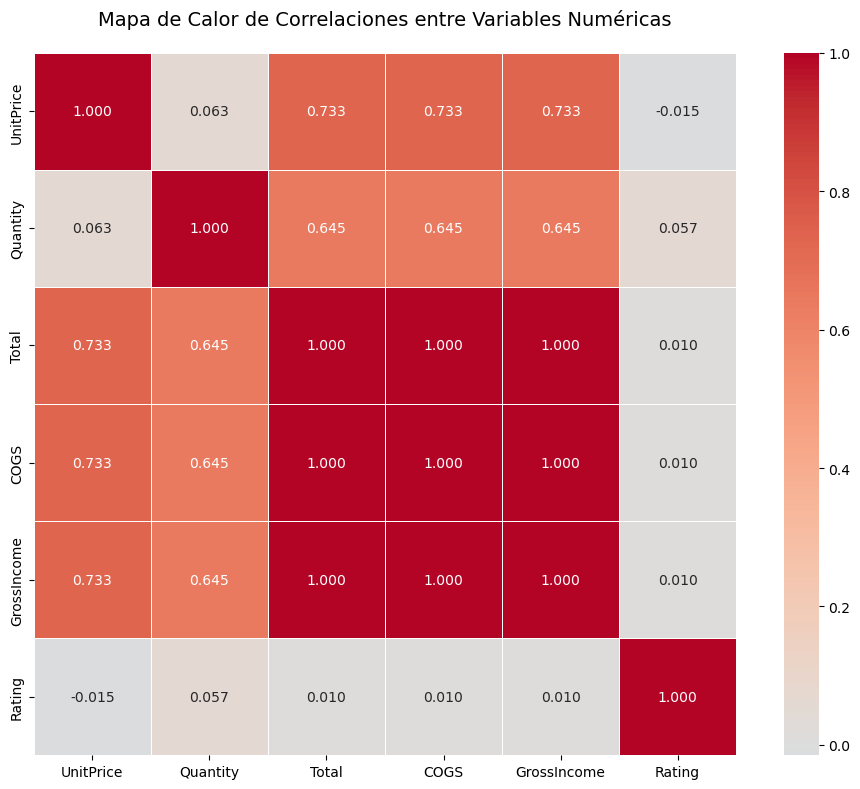


Correlaciones más fuertes :
COGS         Total          1.000000
Total        COGS           1.000000
GrossIncome  Total          1.000000
Total        GrossIncome    1.000000
GrossIncome  COGS           1.000000
COGS         GrossIncome    1.000000
GrossIncome  UnitPrice      0.732904
UnitPrice    GrossIncome    0.732904
             Total          0.732904
Total        UnitPrice      0.732904
dtype: float64


In [103]:
# Seleccionamos solo variables numéricas

df_numericos = df_clean[colum_numericas]

# Matriz de correlación
matriz_cor = df_numericos.corr()

print("Matriz de correlación (Pearson):")
display(matriz_cor.round(3))

# ====================== MAPA DE CALOR ======================
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_cor, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.3f',
            square=True,
            linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones entre Variables Numéricas', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes
print("\nCorrelaciones más fuertes :")
strong_corr = matriz_cor.abs().unstack().sort_values(ascending=False)
strong_corr = strong_corr[strong_corr < 1]  # eliminar diagonal
print(strong_corr.head(10))

### 1.3 Visualización de Datos:
**- 1.3.1 Crear subplots para comparar diferentes variables clave.**


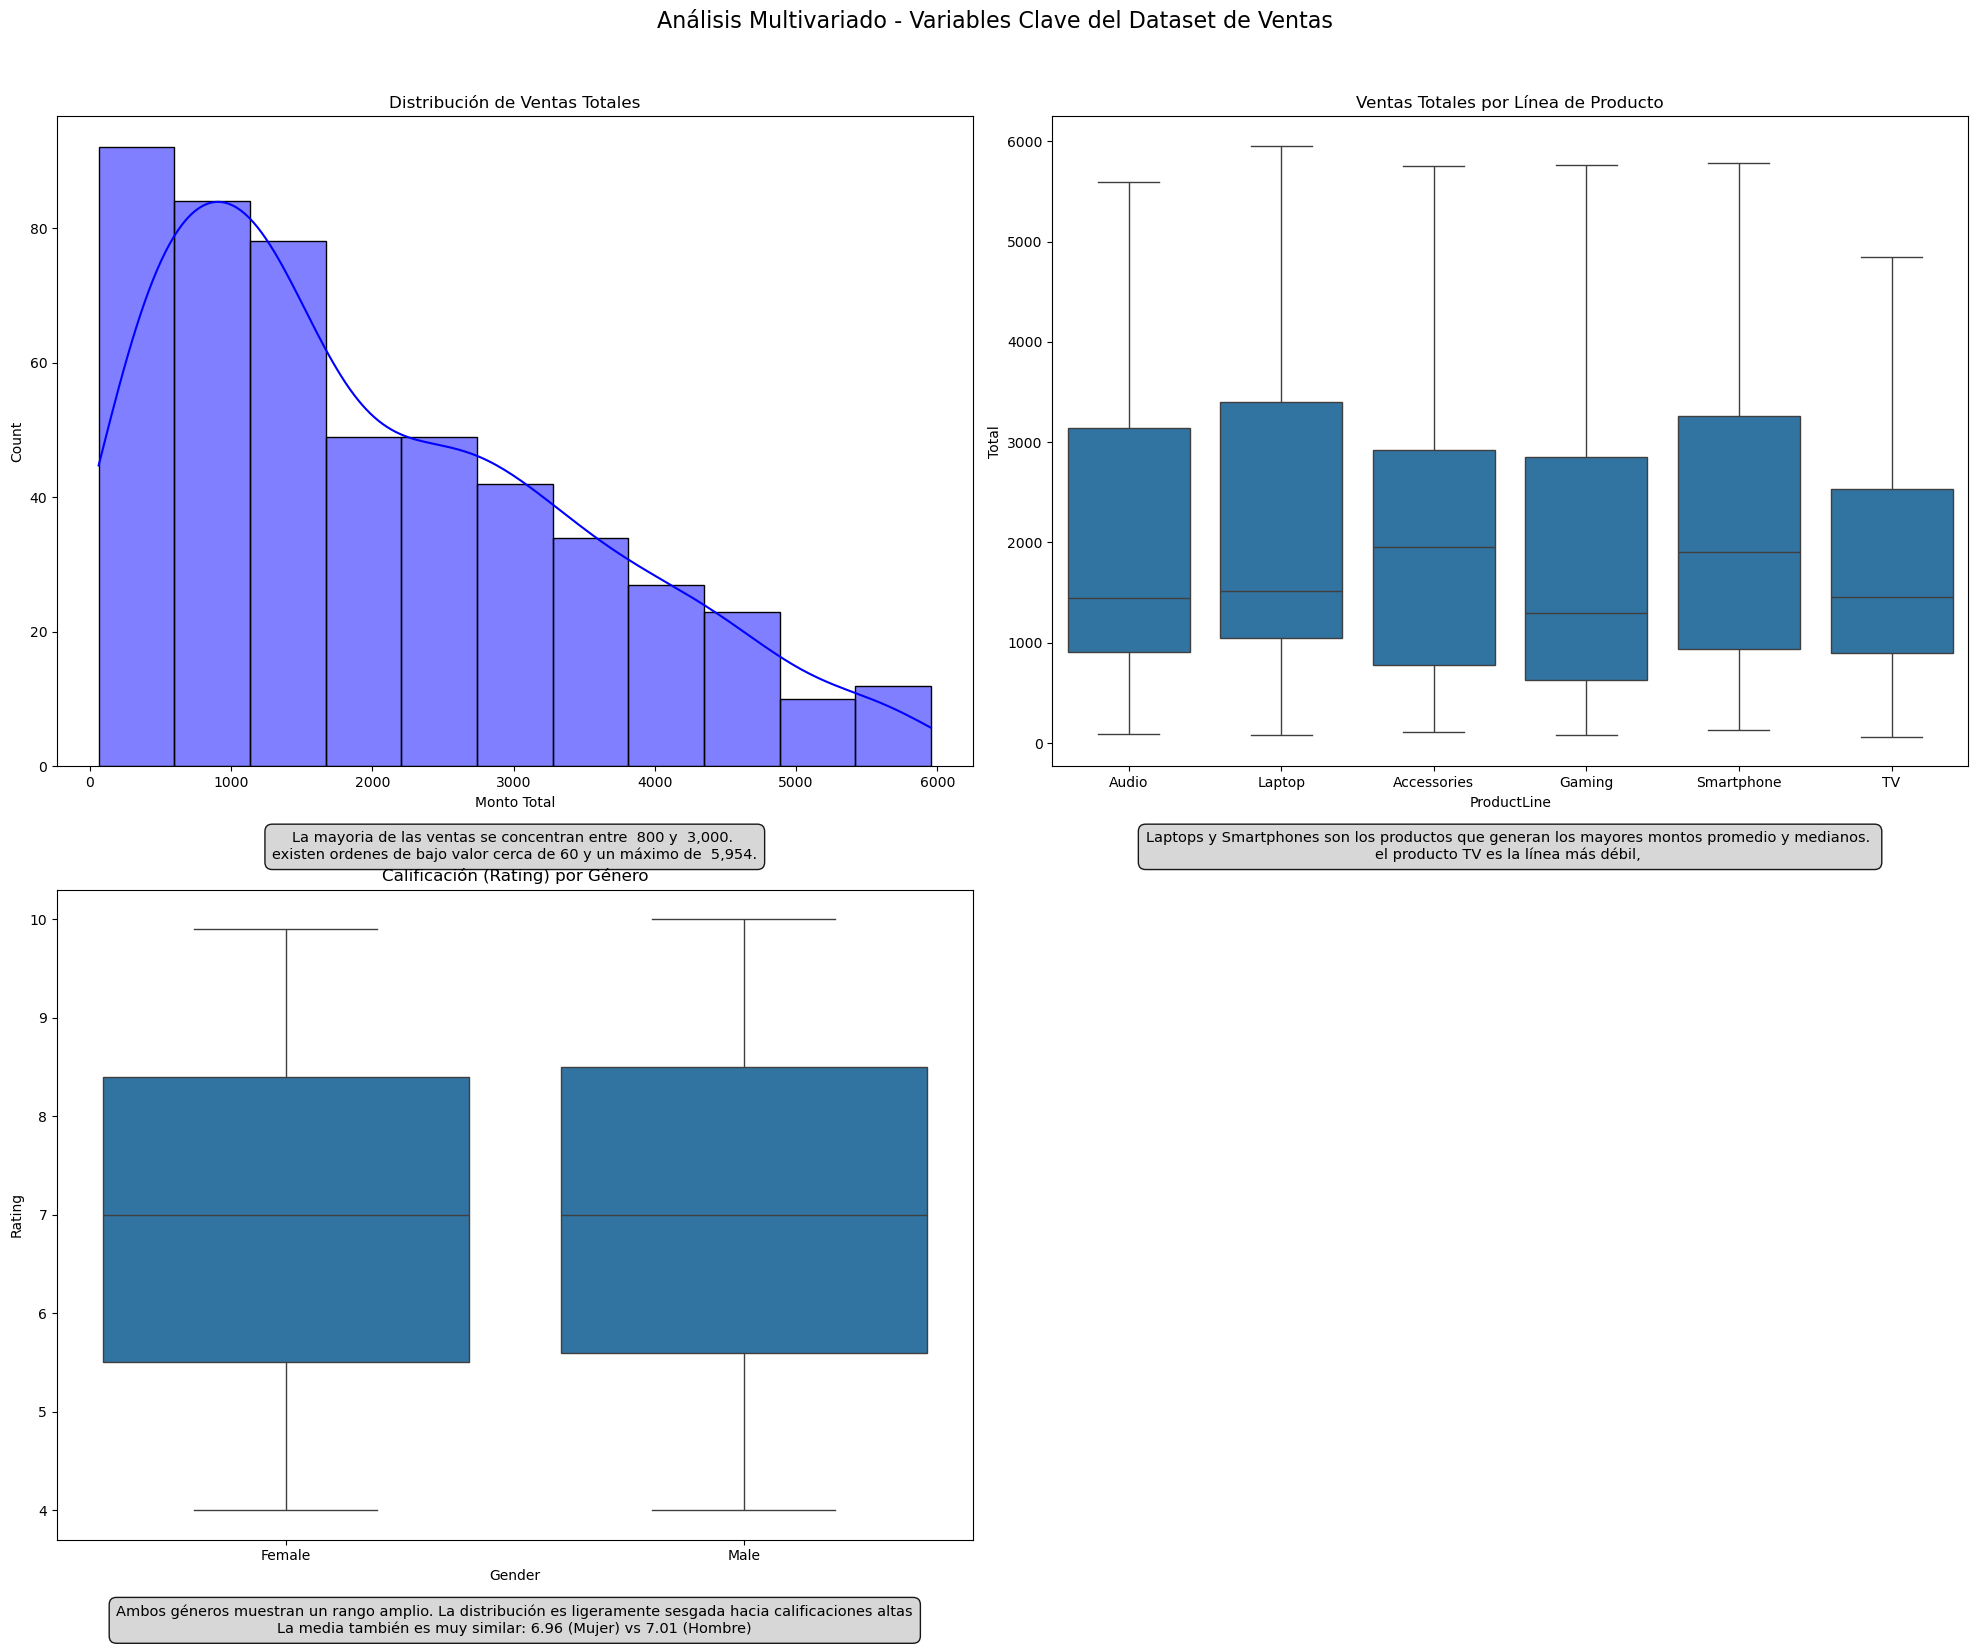

In [104]:
# ====================== CREACIÓN DE SUBPLOTS ======================
fig = plt.figure(figsize=(20, 16))

# 1. Distribución de Ventas Totales
ax1 = plt.subplot(2, 2, 1)
sns.histplot(df_clean['Total'], kde=True, ax=ax1, color='blue')
ax1.set_title('Distribución de Ventas Totales', fontsize=12)
ax1.set_xlabel('Monto Total')

ax1.text(0.5, -0.1, 
        'La mayoria de las ventas se concentran entre  800 y  3,000. \n'
        'existen ordenes de bajo valor cerca de 60 y un máximo de  5,954.',
         transform=ax1.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


# 2. Ventas Totales por Línea de Producto (Boxplot)
ax2 = plt.subplot(2, 2, 2)
sns.boxplot(x='ProductLine', y='Total', data=df_clean, ax=ax2)
ax2.set_title('Ventas Totales por Línea de Producto')

ax2.text(0.5, -0.1, 
        'Laptops y Smartphones son los productos que generan los mayores montos promedio y medianos. \n'
        'el producto TV es la línea más débil, ',
         transform=ax2.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


# 3. Calificación por Género
ax3 = plt.subplot(2, 2, 3)
sns.boxplot(x='Gender', y='Rating', data=df_clean, ax=ax3)
ax3.set_title('Calificación (Rating) por Género')

ax3.text(0.5, -0.1, 
        'Ambos géneros muestran un rango amplio. La distribución es ligeramente sesgada hacia calificaciones altas\n'
        'La media también es muy similar: 6.96 (Mujer) vs 7.01 (Hombre)',
         transform=ax3.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


plt.suptitle('Análisis Multivariado - Variables Clave del Dataset de Ventas', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**1.3.2 Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información**

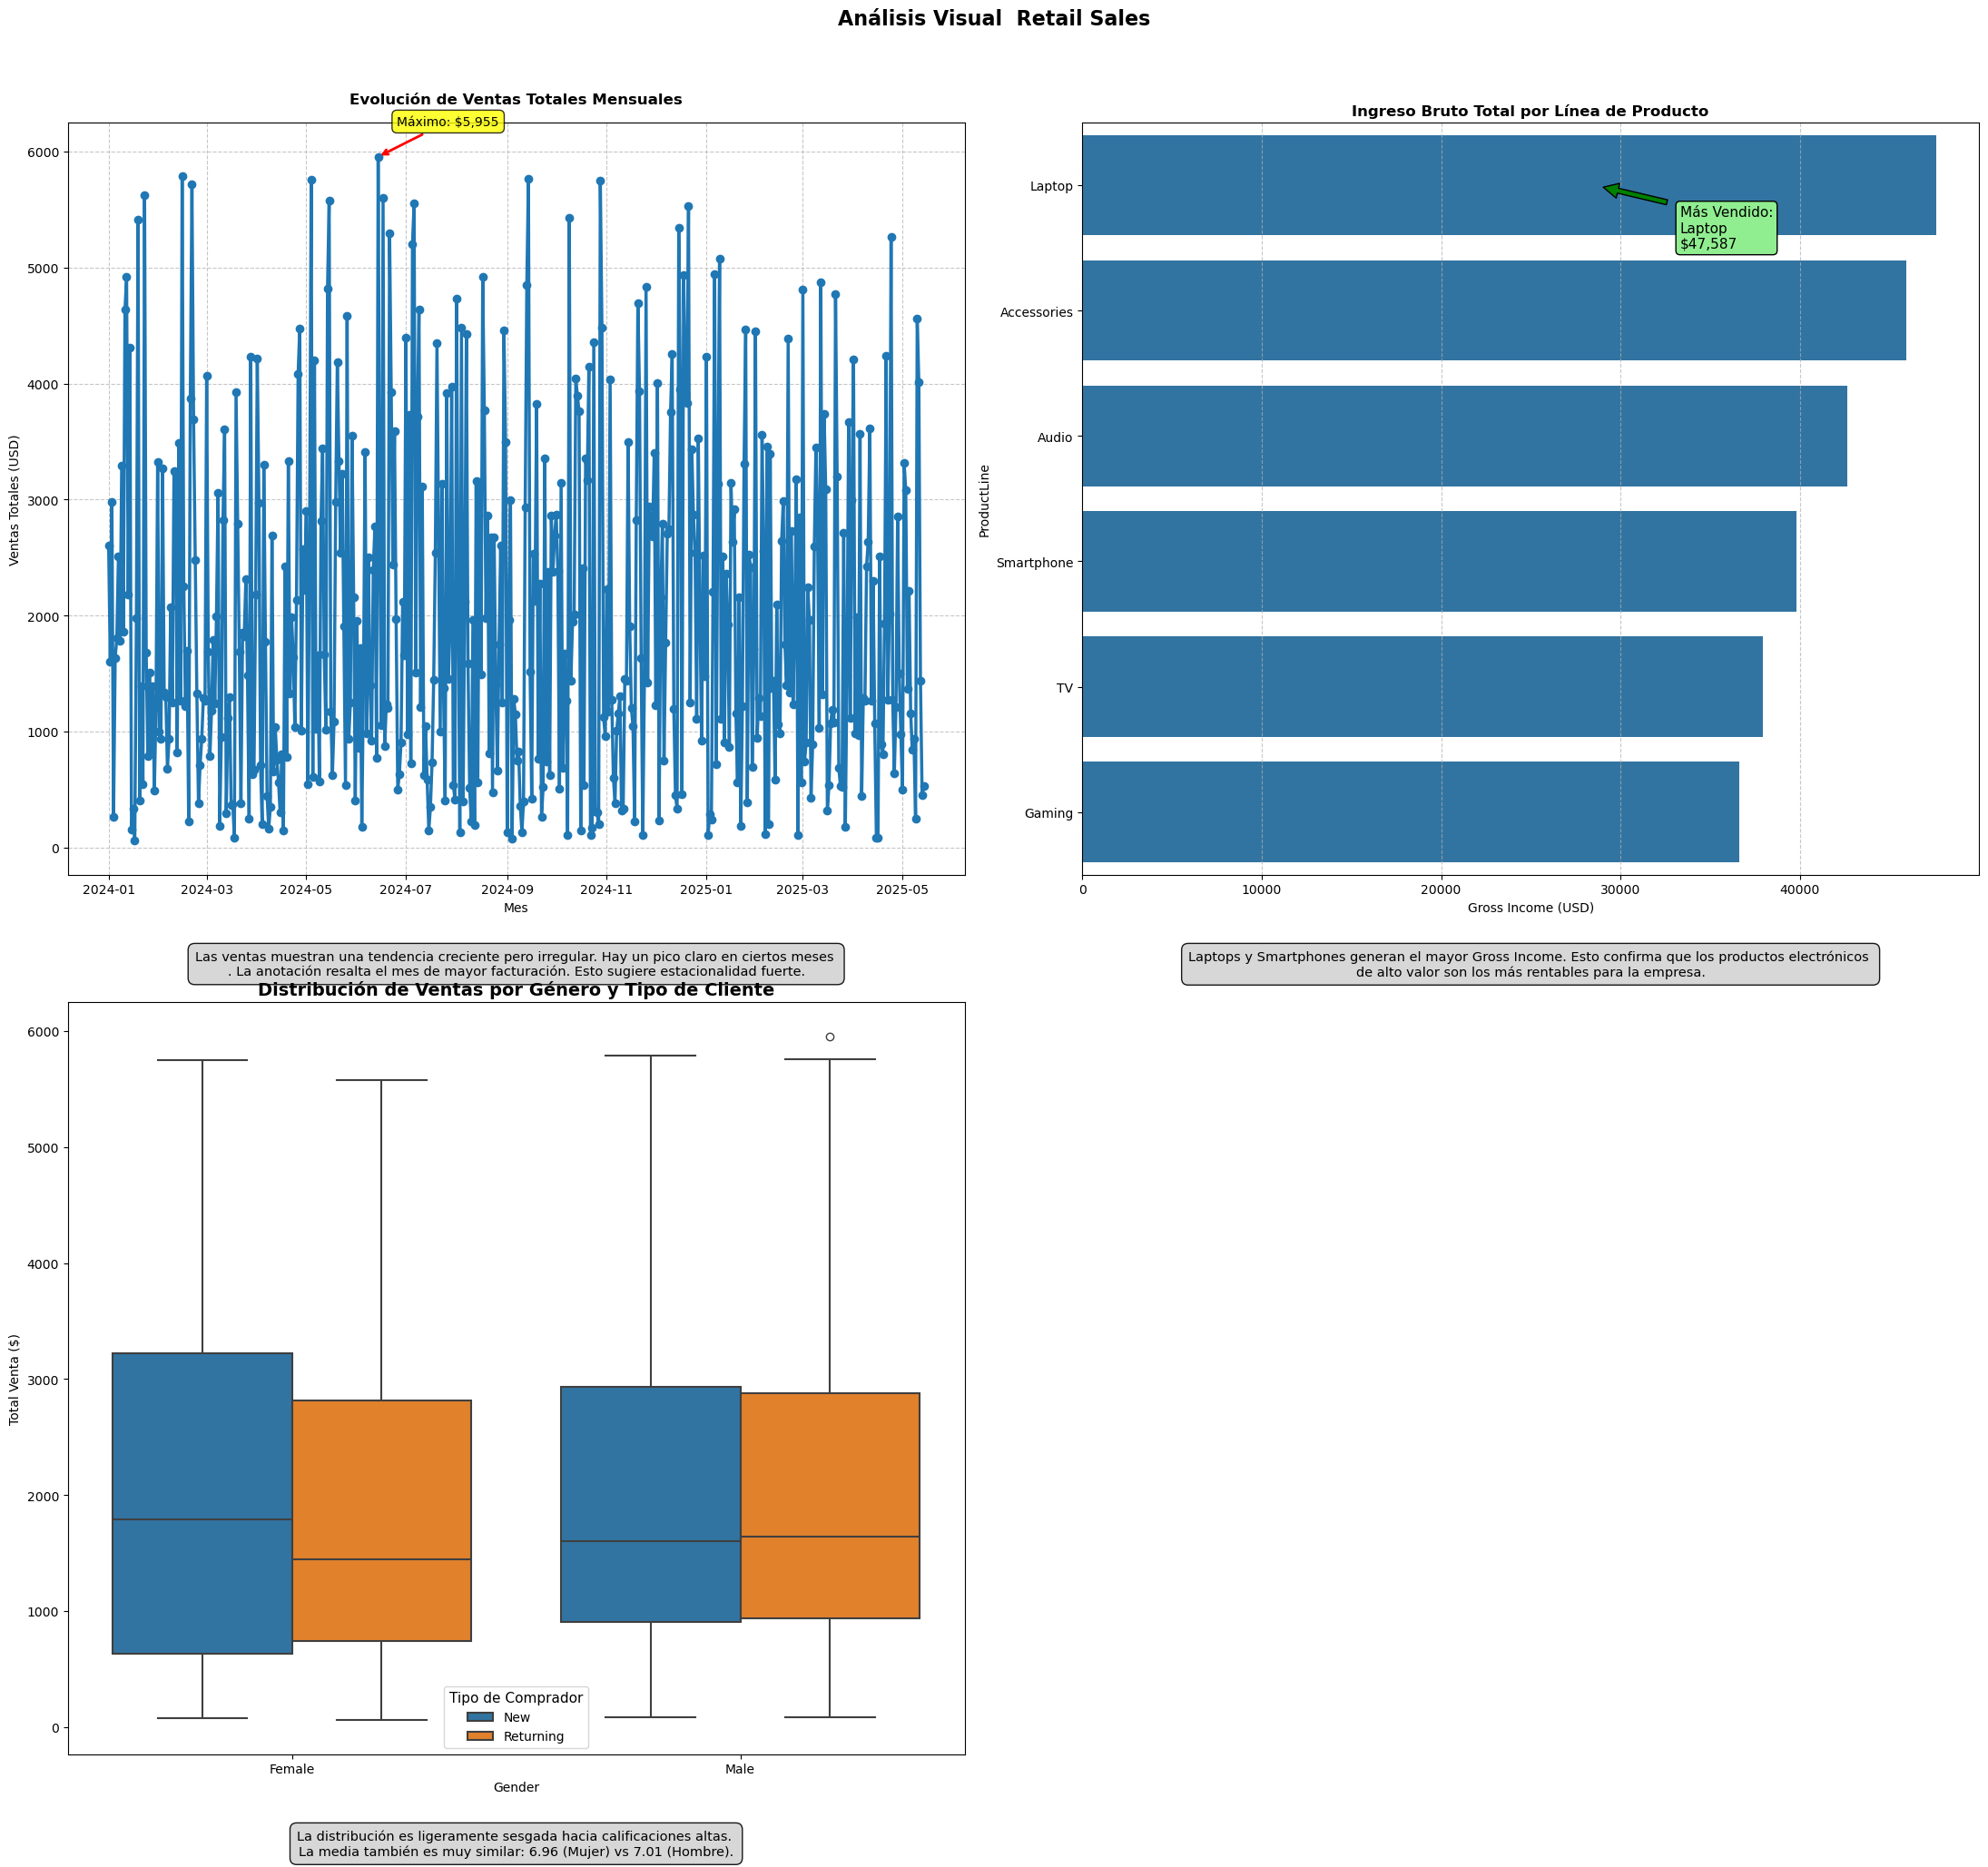

In [105]:

monthly_sales = df_clean.groupby('OrderDate')['Total'].sum().reset_index()
monthly_sales['OrderDate'] = pd.to_datetime(monthly_sales['OrderDate'] + '-01')


fig = plt.figure(figsize=(22, 20))
#grafico Ventas Totales Mensuales


ax1 = plt.subplot(2, 2, 1)
ax1.plot(monthly_sales['OrderDate'], monthly_sales['Total'], 
         marker='o', linewidth=2.5, color='#1f77b4', markersize=6)
ax1.set_title('Evolución de Ventas Totales Mensuales', fontweight='bold', pad=15)
ax1.set_xlabel('Mes')
ax1.set_ylabel('Ventas Totales (USD)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax1.text(0.5, -0.1, 
        'Las ventas muestran una tendencia creciente pero irregular. Hay un pico claro en ciertos meses \n'
        '. La anotación resalta el mes de mayor facturación. Esto sugiere estacionalidad fuerte.',
         transform=ax1.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

# flecha 
max_idx = monthly_sales['Total'].idxmax()
max_month = monthly_sales.loc[max_idx]
ax1.annotate(f'Máximo: ${max_month["Total"]:,.0f}',
             xy=(max_month['OrderDate'], max_month['Total']),
             xytext=(15, 25), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8))

#grafico Ingreso Bruto por Producto 
ax2 = plt.subplot(2, 2, 2)
product_income = df_clean.groupby('ProductLine')['GrossIncome'].sum().sort_values(ascending=False)
sns.barplot(x=product_income.values, y=product_income.index, ax=ax2)
ax2.set_title('Ingreso Bruto Total por Línea de Producto', fontweight='bold')
ax2.set_xlabel('Gross Income (USD)')
ax2.grid(True, axis='x', linestyle='--', alpha=0.7)


ax2.text(0.5, -0.1, 
        'Laptops y Smartphones generan el mayor Gross Income. Esto confirma que los productos electrónicos \n'
        'de alto valor son los más rentables para la empresa.',
         transform=ax2.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


top_c = product_income.index[0]
top_v = product_income.values[0]
ax2.annotate(f'Más Vendido:\n{top_c}\n${top_v:,.0f}', 
                    xy=(top_v*0.6, 0), xytext=(top_v*0.7, 0.5),
                    arrowprops=dict(facecolor='green', shrink=0.1),
                    fontsize=11, bbox=dict(boxstyle="round", facecolor="lightgreen"))


#grafico por Género y Tipo de Cliente ====================
ax3 = plt.subplot(2, 2, 3)
sns.boxplot(x='Gender', y='Total', hue='CustomerType', data=df_clean, ax=ax3, linewidth=1.5)
ax3.set_title('Distribución de Ventas por Género y Tipo de Cliente', fontsize=14, fontweight='bold')
ax3.set_ylabel('Total Venta ($)')
ax3.legend(title='Tipo de Comprador', title_fontsize=11)

ax3.text(0.5, -0.1, 
        'La distribución es ligeramente sesgada hacia calificaciones altas. \n'
        'La media también es muy similar: 6.96 (Mujer) vs 7.01 (Hombre).',
         transform=ax3.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))







plt.suptitle('Análisis Visual Profesional del Dataset de Ventas Minoristas\n'
             'Subplots con cuadrículas, leyendas, anotaciones y flechas', 
             fontsize=18, fontweight='bold')

# Título general
plt.suptitle('Análisis Visual  Retail Sales', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Parte 2: Preprocesamiento de Datos

**- 2.1 Transformación de Columnas:**



- 2.1.1 Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.


In [106]:

col_numericas = ['UnitPrice', 'Quantity', 'Total', 'COGS', 'GrossIncome', 'Rating']
col_categoricas = ['Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'Payment']
col_fecha = ['OrderDate']          # se puede quitar
col_nulas = ['OrderID', 'GrossMargin']   # casi seguro se pueden eliminar


procesadas = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), col_numericas),           # escalar a numericas
        ('categoricas', OneHotEncoder(drop='first', sparse_output=False), col_categoricas),  # tranformar con One-Hot
         ],
    remainder='drop'   #se  elimina OrderID y GrossMargin
)

# Aplicar la transformación
final_proc = procesadas.fit_transform(df_clean)

# Ver resultado
print("Shape después de transformación:", final_proc.shape , '\n ')



Shape después de transformación: (500, 19) 
 


- 2.1.2 Realizar codificación de variables categóricas y escalado de variables numéricas.


In [107]:
# Convertir a DataFrame con nombres de columnas
feature_names = procesadas.get_feature_names_out()
df_esc = pd.DataFrame(final_proc, columns=feature_names)


print(f"Shape original: {df.shape}")
print(f"Shape despues de codificacioon y escalado: {df_esc.shape}")
print("\nPrimeras 5 filas del dataset transformado:")
display(df_esc.head())


Shape original: (500, 14)
Shape despues de codificacioon y escalado: (500, 19)

Primeras 5 filas del dataset transformado:


,numericas__UnitPrice,numericas__Quantity,numericas__Total,numericas__COGS,numericas__GrossIncome,numericas__Rating,categoricas__Branch_B,categoricas__Branch_C,categoricas__City_Mexico City,categoricas__City_Monterrey,categoricas__CustomerType_Returning,categoricas__Gender_Male,categoricas__ProductLine_Audio,categoricas__ProductLine_Gaming,categoricas__ProductLine_Laptop,categoricas__ProductLine_Smartphone,categoricas__ProductLine_TV,categoricas__Payment_Credit Card,categoricas__Payment_Ewallet
0,1.274060,-0.505739,0.406335,0.406336,0.406331,-0.507567,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.074710,-0.505739,-0.277812,-0.277809,-0.277821,0.523375,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.064312,1.275031,0.663719,0.663717,0.663724,-1.309411,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.644422,0.384646,-1.198716,-1.198719,-1.198707,1.325219,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.544859,0.384646,-0.257877,-0.257877,-0.257877,0.007904,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


**- 2.2 Pipelines:**


- 2.2.1 Crear pipelines para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.

In [108]:

# Definir columnas
col_num = [col for col in df if df[col].dtype in ['int64', 'float64']]
col_cat = [col for col in df if df[col].dtype == 'object']

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_num),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), col_cat)
    ],
    remainder='drop'   # Elimina OrderID, OrderDate y GrossMargin%
)

# Pipeline completo
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Aplicar pipeline
X_processed = preprocessing_pipeline.fit_transform(df)

print("Shape después del preprocesamiento:", X_processed.shape)
print("Pipeline creado y aplicado correctamente ")


# Guardar
joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')



Shape después del preprocesamiento: (500, 1017)
Pipeline creado y aplicado correctamente 


['preprocessing_pipeline.pkl']

In [109]:
# Transformar nuevos datos
data_transformada = preprocessing_pipeline.transform(df_clean)
display("nuevos datos transformados con el pipeline : ")

'nuevos datos transformados con el pipeline : '

### 3.- Benchmarking de Técnicas de Machine Learning

#### 3.1 Selección de Modelos:
- **3.1.1 Entrenar y evaluar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).**


In [110]:


X = df_clean.drop(['GrossIncome', 'Total', 'COGS', 'OrderID', 'OrderDate'], axis=1)
y = df_clean['Total']

num_cols = ['UnitPrice', 'Quantity', 'Rating']
cat_cols = ['Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'Payment']


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
], verbose_feature_names_out=False)   # Limpia los nombres


# Mantener nombres de columnas
preprocessor.set_output(transform="pandas")

# ==================== PIPELINES DE MODELOS ====================
models = {
    'LinearRegression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'LGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

results = []
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Modelo': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    })

# Los resultados
results_df = pd.DataFrame(results).round(4)
print(results_df.sort_values(by='R²', ascending=False))


             Modelo       MAE      RMSE      R²
3      RandomForest   28.4481   41.5969  0.9992
4           XGBoost   35.6538   51.0103  0.9988
5              LGBM   44.5798   64.7639  0.9981
2      DecisionTree   46.2780   74.8182  0.9975
0  LinearRegression  388.5358  487.1004  0.8939
1               KNN  362.8245  487.5870  0.8937


### Comentarios:
##### - el desempeño general es de los moldelos es excelente tienen un buen rendimiento con un R2 a 0.99 los errores del Mae son bajos entre $28 y $46 y el ganador de los modelos es RandomForest




- **3.1.2 Utilizar validación cruzada para evaluar el rendimiento de los modelos.**


In [111]:
# Eliminar filas con nulos para correlación
df_cod  = df_clean[colum_numericas].copy()
df_cod = df_cod.dropna()

# Matriz de correlación
correlacion = df_cod.corr()

# Correlación
#print('\ncolumnas con correlacion a columna total: \n',correlacion['Total'].sort_values(ascending=False).round(4))

# Filtrar características altamente correlacionadas con la variable objetivo mayor a 0.5
objetivo_corr = abs(correlacion['Total'])
columnas_relevantes = objetivo_corr[objetivo_corr > 0.5]
# print('\n columnas importantes con correlacion mayor a 0.5 : \n ',columnas_relevantes.index)
# display("dataframe con encoding de las variables categoricas : ", df_cod.head(10))

X = df_cod.drop(columns=['Total'])
y = df_cod['Total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1
).fit(X_train, y_train)

print(f'Combinaciones probadas: {3*3*3} × 5 folds = 135 entrenamientos')
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'R² en test:              {grid.score(X_test, y_test):.4f}')


modelos = {
    'Lineal':  make_pipeline(StandardScaler(), LinearRegression()),
    'KNN':     make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    'Árbol':   DecisionTreeRegressor(max_depth=10, random_state=42),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'GBR':     GradientBoostingRegressor(n_estimators=100, random_state=42)
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla.round(4))

# Tuning del ganador (asumimos RF)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')




Combinaciones probadas: 27 × 5 folds = 135 entrenamientos
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
R² en test:              0.9999
Benchmark:
Lineal    1.0000
RF        0.9999
GBR       0.9999
Árbol     0.9996
KNN       0.9950
dtype: float64

Mejor RF tuned: {'max_depth': 10, 'n_estimators': 200}
R² sin tuning: 0.9999
R² con tuning: 0.9999


### Interpretacion :
#####  en la Validacion cruzada  se confirma que los modelos tienen un rendimiento alto para predecir  el total de ventas . en los modelos RF y GB logran un R2 muy alto lo que conlleva a que expliquen  mas del 99% de la variabilidad del monto total

#### 3.2 Comparación de Modelos:
- **3.2.1 Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.**


Train: (350, 16) | Test: (150, 16)
📊 Tabla de rendimientos
           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
KNN(k=11)    0.8133     0.7701  0.8933  0.8272  0.8959
RF(200)      0.9667     0.9487  0.9867  0.9673  0.9960
LogReg       0.9400     0.9459  0.9333  0.9396  0.9876


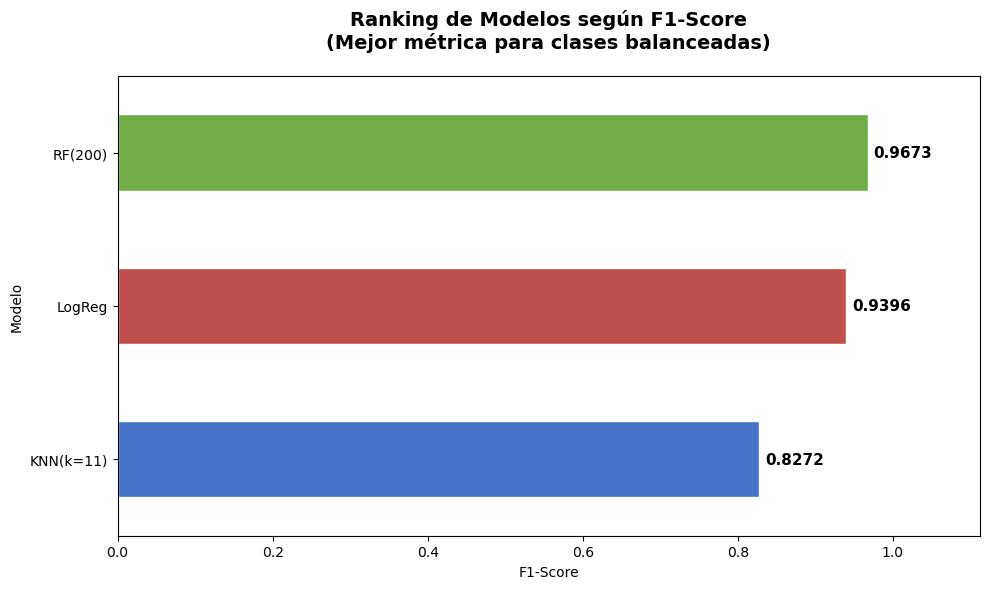


🏆 GANADOR según F1-Score: RF(200) con F1 = 0.9673


In [129]:
# Crear variable objetivo binaria
median_total = df['Total'].median()
df['HighValue'] = (df['Total'] > median_total).astype(int)

# columnas numericas y cargoricas
categorical_cols = ['Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'Payment']
numerical_cols = ['UnitPrice', 'Quantity', 'Rating']

# Codificación one-hot manual para simplicidad
X = pd.get_dummies(df[categorical_cols + numerical_cols], drop_first=True)
y = df['HighValue']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


#  modelos con StandardScaler
modelos = {
    'KNN(k=11)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    'RF(200)':   make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

}

filas = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred  = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'AUC':       roc_auc_score(y_test, proba)
    })

tabla = pd.DataFrame(filas).set_index('Modelo').round(4)

print("📊 Tabla de rendimientos")
print(tabla)

# ====================== 4. VISUALIZACIÓN ======================
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#4472C4', '#C0504D', '#70AD47', '#ED7D31']
tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)

for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.008, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_title('Ranking de Modelos según F1-Score\n(Mejor métrica para clases balanceadas)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('F1-Score')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.savefig('reports/classification_report.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Ganador
ganador = tabla['F1'].idxmax()
print(f"\n🏆 GANADOR según F1-Score: {ganador} con F1 = {tabla.loc[ganador, 'F1']:.4f}")



### interpretacion : 
##### se creo una variable binaria HighValue (1 = venta alta , 0 = venta baja) usando la mediana del total. esto conviete el problema en una clasificacion binaria 
- **Accuracy: percentaje de predicciones  correctas logra un 96.67% RF**
- **Presicion: las ordenes del modelo que predice de "HighValue" de RF son del 94.87 y es bajo el riesgo que aparescan  falsos positivoss**
- **Recall : RF destaca con un 98.67% no se le escapan ventas altas.**
- **F1-Score : tiene un resultado Excelente entre la media de Presicion y Recall.**
- **AUC-ROC : tiene una capacidad alta de ditingir entre clases**

- **3.2.2 Seleccionar el mejor modelo basado en las métricas obtenidas.**

In [113]:
modelos = {
    'Lineal':  make_pipeline(StandardScaler(), LinearRegression()),
    'KNN':     make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'GBR':     GradientBoostingRegressor(n_estimators=100, random_state=42)
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla2 = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla2.round(4))


# Tuning del ganador (asumimos RF)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla2["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')


Benchmark:
RF        0.9679
GBR       0.9328
Lineal    0.6519
KNN       0.3728
dtype: float64

Mejor RF tuned: {'max_depth': 10, 'n_estimators': 200}
R² sin tuning: 0.9679
R² con tuning: 0.9679


### 4.- Análisis de Métricas

**4.1  Informe de Clasificación:**



- 4.1.1 Generar un informe de clasificación para los modelos evaluados.


In [114]:
# Preparación
X = df_clean.drop(['GrossIncome', 'Total', 'COGS', 'OrderID', 'OrderDate'], axis=1)
y = df_clean['GrossIncome']

num_cols = ['UnitPrice', 'Quantity', 'Rating']
cat_cols = ['Branch', 'City', 'CustomerType', 'Gender', 'ProductLine', 'Payment']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

models = {
    'LinearRegression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

print("se generara los modelos")

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Modelo': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })

# Crear DataFrame y mostrar informe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

print("Informe de Desempeño \n")

print(results_df.to_string(index=False))

print(f"Mejor modelo: **{results_df.iloc[0]['Modelo']}** con R² = {results_df.iloc[0]['R²']}")

se generara los modelos
Informe de Desempeño 

          Modelo     MAE     RMSE     R²
    RandomForest  7.1066  10.5423 0.9992
         XGBoost  8.7974  12.7273 0.9988
    DecisionTree  9.9116  15.0618 0.9984
        LightGBM 11.1894  16.1187 0.9981
LinearRegression 96.7946 121.3497 0.8939
             KNN 90.3890 121.4710 0.8937
Mejor modelo: **RandomForest** con R² = 0.9992


c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Interpretacion :
##### El rendimiento de los modelos basados en arboles logran sobre los 0.96 de la variabilidad del total de ventas. los modelos debiles como la regression Lineal e el KNN quedan muy rezagados a los rtendimientos de arboles. Por este motivo el modelo de Random Forest permite predicir el monto de ventas , con un nivel de presicion para tomar decisiones operativas y estrategicas

- 4.1.2 Incluir la matriz de confusión para una comprensión detallada de los errores de clasificación.

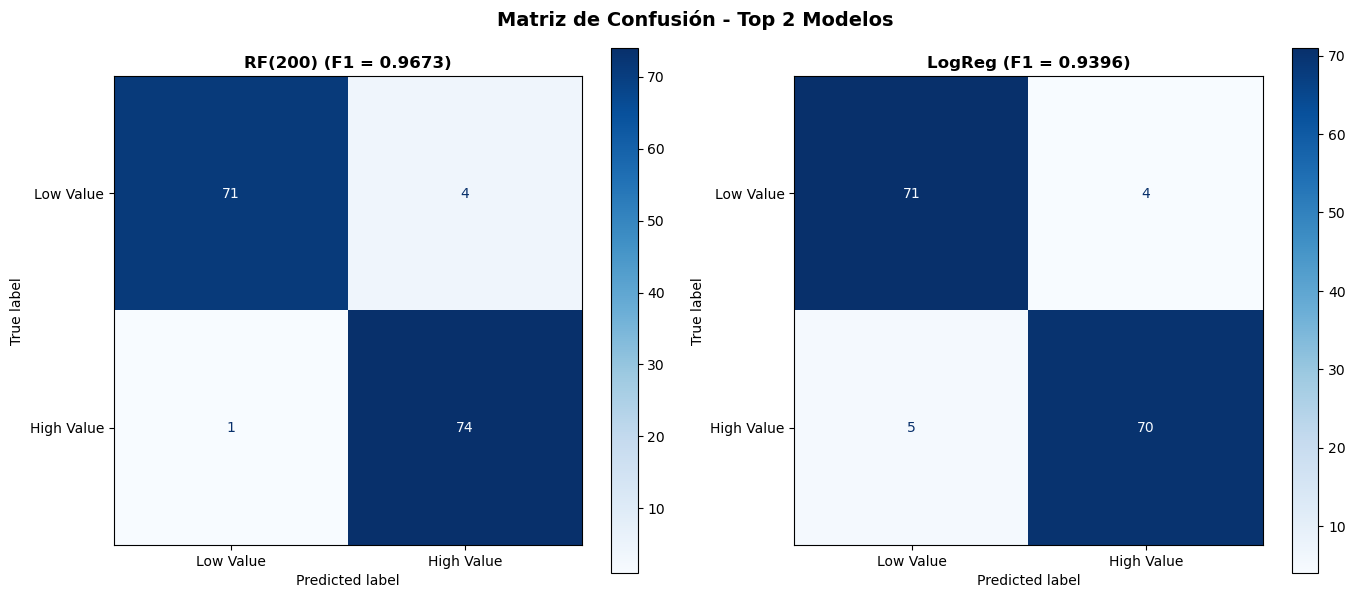

In [130]:
ranking_f1 = tabla['F1'].sort_values(ascending=False).head(2).index.tolist()
# Matrices de los 2 mejores + curvas ROC de los 4
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Matrices de los 2 mejores por F1
for i, nombre in enumerate(ranking_f1):
    y_pred = modelos[nombre].predict(X_test)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], cmap='Blues',

        display_labels=['Low Value', 'High Value']
    )
    axes[i].set_title(f'{nombre} (F1 = {tabla.loc[nombre, "F1"]:.4f})', 
                      fontweight='bold')

plt.suptitle('Matriz de Confusión - Top 2 Modelos', fontsize=14, fontweight='bold')
plt.savefig('reports/confusion_matrix.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()    

### Interpretacion : 
##### - **Tiene un buen rendimiento con muy pocos errores totales , tiene muy bajo numero de falso positivos , el modelo es altamente confiable para clasificar**

**4.2 Curva ROC y AUC:**
- 4.2.1 Crear y visualizar la curva ROC para los modelos de clasificación binaria.


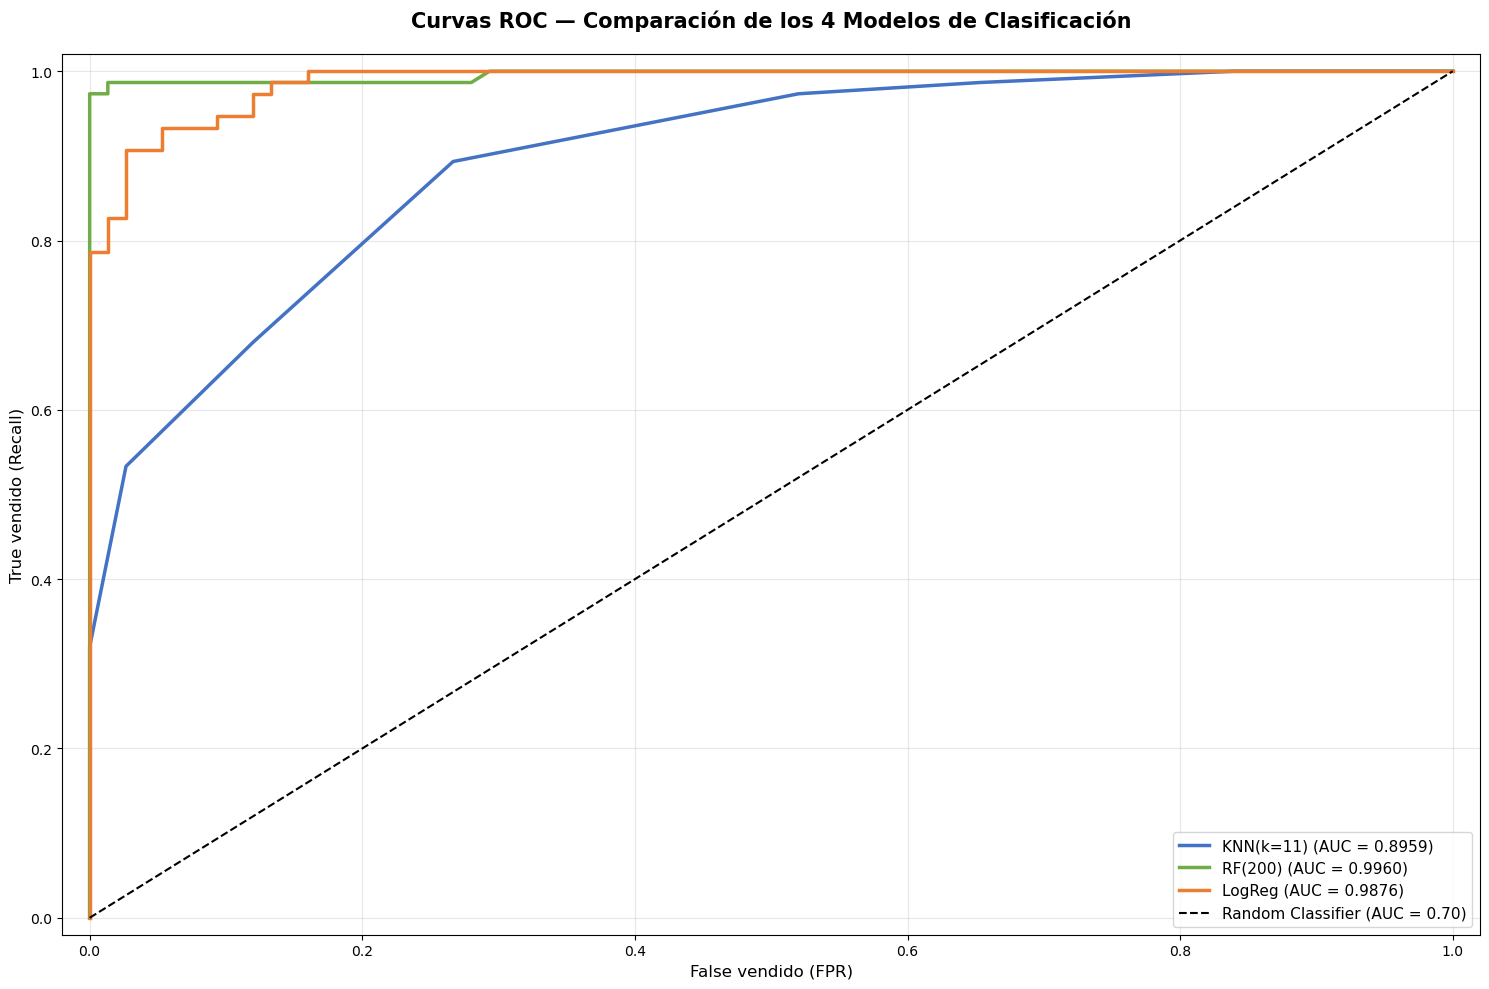

In [131]:
fig, ax = plt.subplots(figsize=(15, 10))

colores_roc = {
    'KNN(k=11)': '#4472C4',
    'DT(d=5)':   '#C0504D',
    'RF(200)':   '#70AD47',
    'LogReg':    '#ED7D31'
}

for nombre, modelo in modelos.items():
    # Obtener probabilidades
    proba = modelo.predict_proba(X_test)[:, 1]
    
    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
 #   print("auc",auc)
    # Graficar
    ax.plot(fpr, tpr, 
            color=colores_roc[nombre], 
            linewidth=2.5,
            label=f'{nombre} (AUC = {auc:.4f})')

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.70)')

# Personalización
ax.set_xlabel('False vendido (FPR)', fontsize=12)
ax.set_ylabel('True vendido (Recall)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de los 4 Modelos de Clasificación', 
             fontsize=15, fontweight='bold', pad=20)

ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)


# Ajustes finales
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.savefig('reports/roc_curve.png', dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Interpretacion : 
#### El gráfico muestra que todos los modelos tienen un muy buen desempeño, pero con claras diferencias: 
**- Random Forest: tiene una excelente capacidad para distinguir entre los 'Low Value' y 'High Value'**
**- Logistic Regresion: es un modelo aceptable, donde se pueden explicar las decisiones.**
**- KNN: Tiene una menor capacidad discrimitativa en umbrales intermedios**


- 4.2.2 Calcular el AUC para evaluar la capacidad del modelo para distinguir entre clases.

In [124]:
# Lista para almacenar resultados
auc_results = []


for nombre, pipeline in modelos.items():
    # Probabilidades de la clase positiva (HighValue = 1)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcular AUC
    auc = roc_auc_score(y_test, y_proba)
    
    auc_results.append({
        'Modelo': nombre,
        'AUC': round(auc, 4),
        'Interpretación': 'Excelente' if auc >= 0.9 else 
                         'Muy Bueno' if auc >= 0.8 else 
                         'Bueno' if auc >= 0.7 else 'Aceptable'
    })

# Crear DataFrame y ordenar
auc_df = pd.DataFrame(auc_results)
auc_df = auc_df.sort_values(by='AUC', ascending=False).reset_index(drop=True)

# Mostrar tabla

print(auc_df.to_string(index=False))

# Resumen final
print("\n")
mejor_modelo = auc_df.iloc[0]['Modelo']
mejor_auc = auc_df.iloc[0]['AUC']
print(f"🏆 MEJOR MODELO SEGÚN AUC: **{mejor_modelo}**")
print(f"AUC = {mejor_auc:.4f} → {auc_df.iloc[0]['Interpretación']} ")



   Modelo    AUC Interpretación
  RF(200) 0.9960      Excelente
   LogReg 0.9876      Excelente
KNN(k=11) 0.8959      Muy Bueno


🏆 MEJOR MODELO SEGÚN AUC: **RF(200)**
AUC = 0.9960 → Excelente 
